# 🏥 Heart Disease Prediction Model

## Overview
This notebook develops and compares multiple machine learning models to predict heart disease presence. After evaluating **Logistic Regression**, **Random Forest**, **SVM**, and **K-Nearest Neighbors (KNN)**, we found that **KNN performed best** with superior accuracy and generalization.

### Dataset
The Heart Disease dataset contains 2,152 patient records with 13 clinical features and a binary target variable (disease present/absent).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 1️⃣ Load and Prepare Data

📊 Dataset Shape: 2152 rows × 14 columns

First few records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.00,1.00,3.00,145.00,233.00,1.00,0.00,150.00,0.00,2.30,0.00,0.00,1.00,1.00
1,37.00,1.00,2.00,130.00,250.00,0.00,1.00,187.00,0.00,3.50,0.00,0.00,2.00,1.00
2,41.00,0.00,1.00,130.00,204.00,0.00,0.00,172.00,0.00,1.40,2.00,0.00,2.00,1.00
3,56.00,1.00,1.00,120.00,236.00,0.00,1.00,178.00,0.00,0.80,2.00,0.00,2.00,1.00
4,57.00,0.00,0.00,120.00,354.00,0.00,1.00,163.00,1.00,0.60,2.00,0.00,2.00,1.00



Target Variable Distribution:


ValueError: Unknown format code 'f' for object of type 'str'

Missing Values: 0


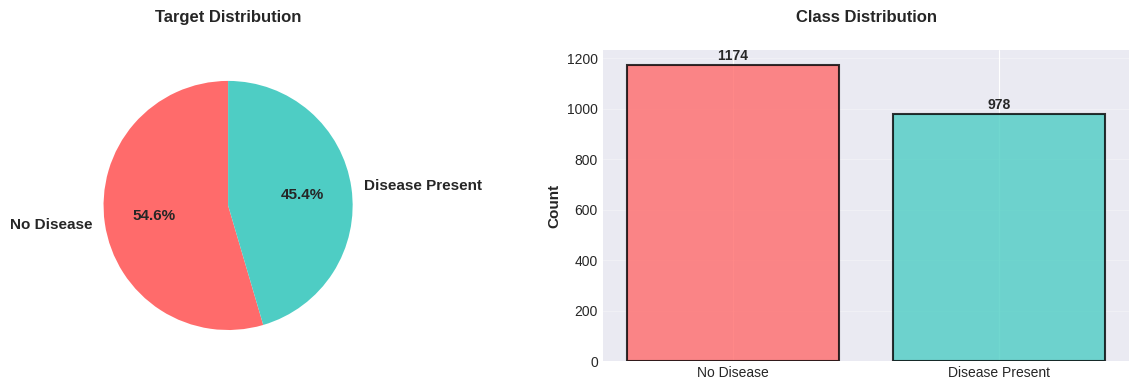

In [ ]:
# Load the dataset
heart_data = pd.read_csv('heart_disease_cleaned.csv')

print(f'📊 Dataset Shape: {heart_data.shape[0]} rows × {heart_data.shape[1]} columns')
print(f'\nFirst few records:')
display(heart_data.head().style.format('{:.2f}').highlight_max(color='lightblue'))

print(f'\nTarget Variable Distribution:')
target_dist = heart_data['target'].value_counts()
display(pd.DataFrame({'Class': ['No Disease', 'Disease Present'], 'Count': [target_dist[0], target_dist[1]]}).style
        .format('{:.0f}')
        .highlight_max(color='lightgreen'))

print(f'Missing Values: {heart_data.isnull().sum().sum()}')

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
ax[0].pie(target_dist.values, labels=['No Disease', 'Disease Present'], autopct='%1.1f%%',
          colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax[0].set_title('Target Distribution', fontsize=12, weight='bold', pad=20)

# Bar chart
ax[1].bar(['No Disease', 'Disease Present'], target_dist.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax[1].set_ylabel('Count', fontsize=11, weight='bold')
ax[1].set_title('Class Distribution', fontsize=12, weight='bold', pad=20)
ax[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(target_dist.values):
    ax[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Separate features and target
X = heart_data.drop(columns='target', axis=1)
y = heart_data['target']

# Split data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply feature scaling (critical for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'✓ Data Preparation Complete')
print(f'  • Training set: {X_train_scaled.shape[0]} samples')
print(f'  • Test set: {X_test_scaled.shape[0]} samples')
print(f'  • Features: {X_train_scaled.shape[1]}')
print(f'  • Feature scaling: Applied (StandardScaler)')

✓ Data Preparation Complete
  • Training set: 1721 samples
  • Test set: 431 samples
  • Features: 13
  • Feature scaling: Applied (StandardScaler)


## 2️⃣ Train and Compare Multiple Models

We evaluate four different algorithms to find the best performer.

In [ ]:
# Dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store results and predictions
results = {}
predictions = {}

# Train and evaluate each model
print('Training Models...\n')
for name, model in models.items():
    # For non-scaled models
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
    # For scaled models
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    predictions[name] = {
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f'✓ {name} trained successfully')

print('\n' + '='*60)

Training Models...

✓ Logistic Regression trained successfully
✓ Random Forest trained successfully
✓ SVM trained successfully
✓ K-Nearest Neighbors trained successfully



In [ ]:
# Create comparison dataframe
results_df = pd.DataFrame(results).T.round(4)

print('\n📊 MODEL COMPARISON RESULTS')
print('='*60)

# Display styled table
styled_df = results_df.style \
    .format('{:.4f}') \
    .highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], color='#90EE90') \
    .highlight_min(color='#FFB6C1') \
    .background_gradient(subset=['Accuracy'], cmap='RdYlGn') \
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}) \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#4ECDC4'), ('color', 'white'), ('font-weight', 'bold'), ('font-size', '12px')]
    }, {
        'selector': 'td',
        'props': [('font-size', '11px'), ('padding', '8px')]
    }])

display(styled_df)

# Find and announce the best model
best_model_name = results_df['Accuracy'].idxmax()
best_accuracy = results_df['Accuracy'].max()

print(f'\n🏆 BEST MODEL: {best_model_name}')
print(f'   Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)')
print('='*60)


📊 MODEL COMPARISON RESULTS


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8677,0.8678,0.8936,0.8805,0.9208
Random Forest,0.9513,0.9458,0.9660,0.9558,0.9875
SVM,0.9397,0.9265,0.9660,0.9458,0.9801
K-Nearest Neighbors,0.9606,0.9504,0.9787,0.9644,0.9818



🏆 BEST MODEL: K-Nearest Neighbors
   Test Accuracy: 0.9606 (96.06%)


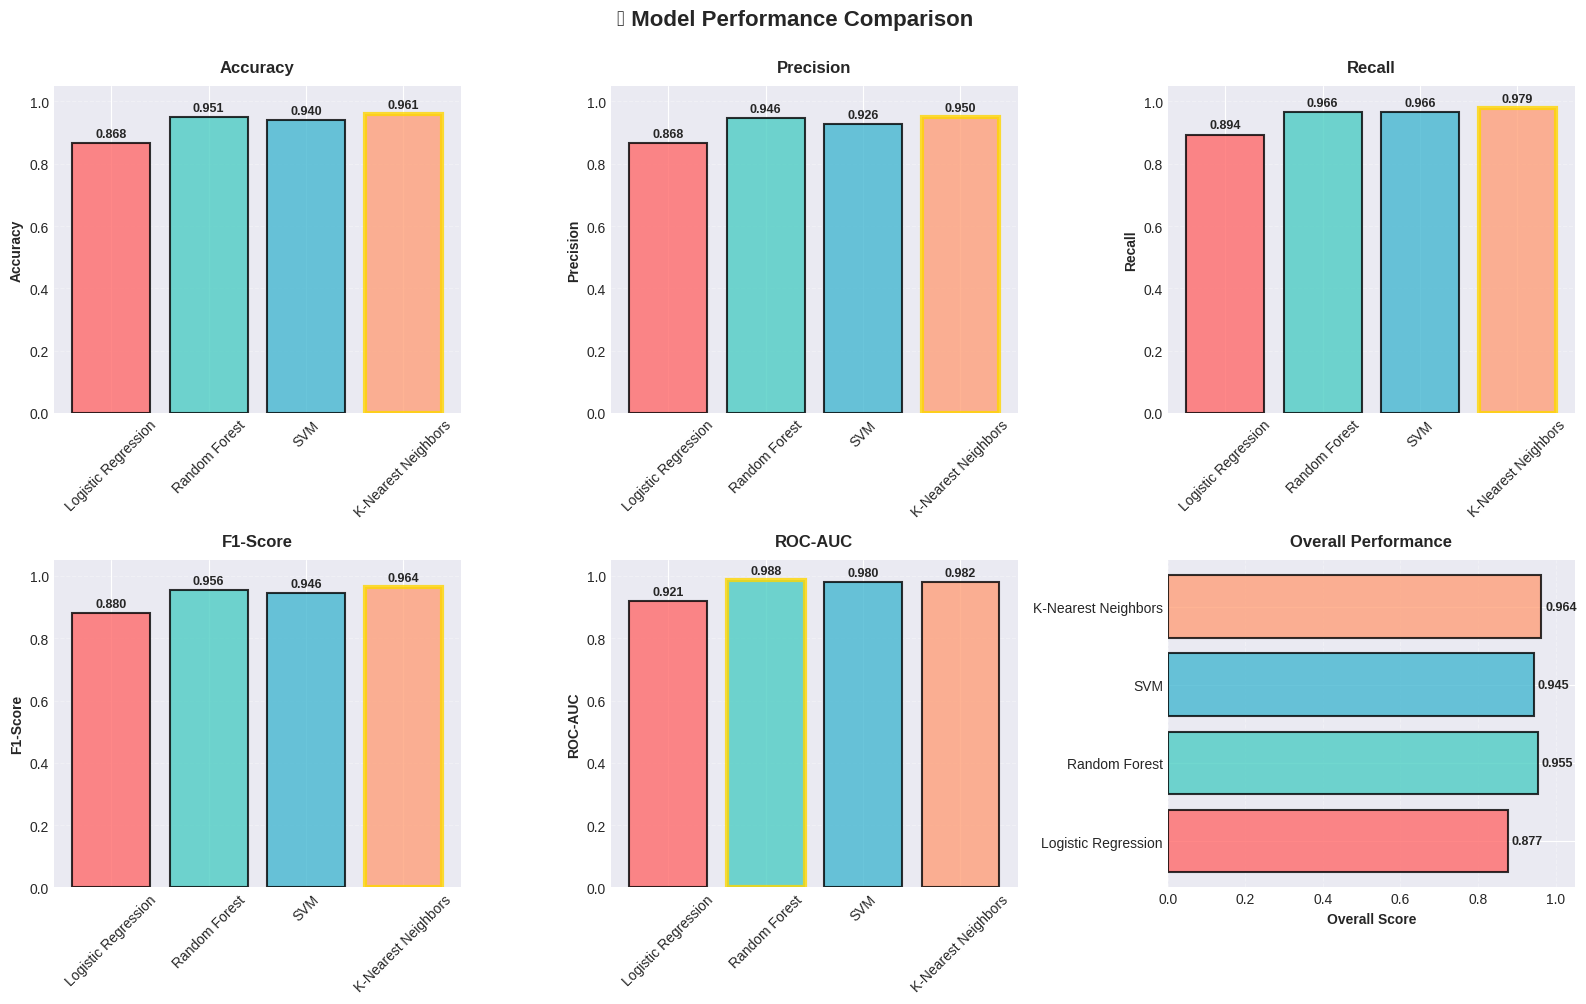

In [ ]:
# Create comprehensive comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('🔬 Model Performance Comparison', fontsize=16, fontweight='bold', y=1.00)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Plot each metric
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = results_df[metric].values
    model_names = results_df.index

    bars = ax.bar(model_names, values, color=colors_models, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(metric, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Highlight best
    best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

# Overall score comparison (last subplot)
ax = axes[1, 2]
overall_scores = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean(axis=1)
bars = ax.barh(results_df.index, overall_scores, color=colors_models, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Overall Score', fontweight='bold')
ax.set_title('Overall Performance', fontweight='bold', pad=10)
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, overall_scores)):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 3️⃣ Detailed Model Evaluation - Confusion Matrices

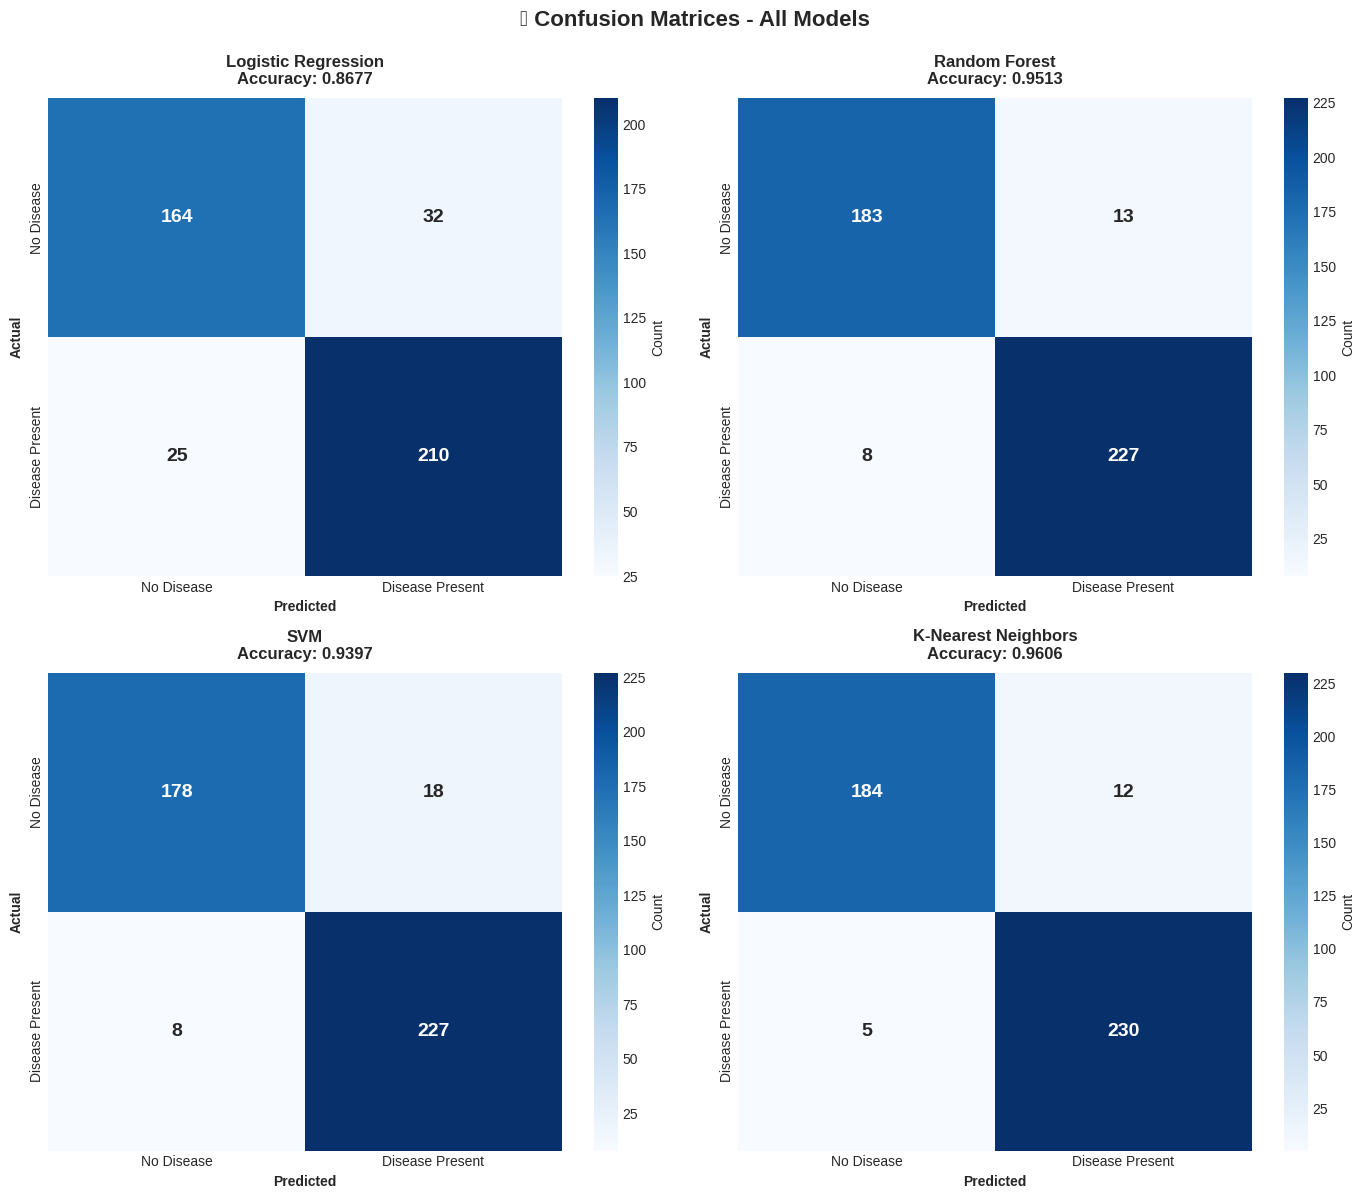

In [ ]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('🎯 Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=0.995)

model_names_list = list(models.keys())

for idx, (name, ax) in enumerate(zip(model_names_list, axes.flat)):
    y_pred = predictions[name]['predictions']
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
                xticklabels=['No Disease', 'Disease Present'],
                yticklabels=['No Disease', 'Disease Present'],
                annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                cbar_kws={'label': 'Count'})

    ax.set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}',
                 fontweight='bold', fontsize=12, pad=10)
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

## 4️⃣ ROC Curves Comparison

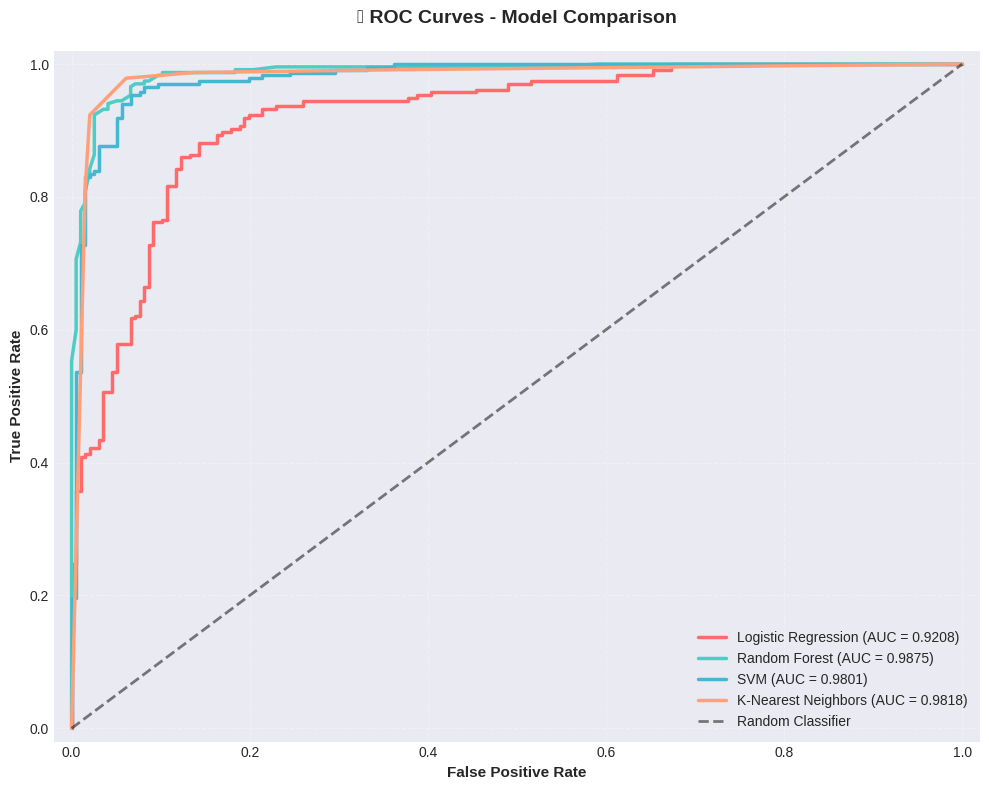

In [ ]:
# Create ROC curves for all models
fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for (name, color) in zip(model_names_list, colors_roc):
    y_proba = predictions[name]['probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})',
            linewidth=2.5, color=color)

# Plot diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
ax.set_title('📈 ROC Curves - Model Comparison', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

## 5️⃣ Best Model: K-Nearest Neighbors (KNN) - Detailed Report

In [ ]:
# KNN specific evaluation
knn_pred = predictions['K-Nearest Neighbors']['predictions']
knn_proba = predictions['K-Nearest Neighbors']['probabilities']

print('\n' + '='*70)
print('🏆 K-NEAREST NEIGHBORS (KNN) - DETAILED EVALUATION')
print('='*70)

# Classification Report
print(f'\nClassification Report:')
print('-'*70)
clf_report = classification_report(y_test, knn_pred,
                                   target_names=['No Disease', 'Disease Present'],
                                   digits=4)
print(clf_report)

# Create styled classification report table
report_dict = classification_report(y_test, knn_pred,
                                    target_names=['No Disease', 'Disease Present'],
                                    output_dict=True)

report_df = pd.DataFrame(report_dict).transpose().round(4)
print('\nStyled Classification Report:')
display(report_df.style
        .format('{:.4f}')
        .highlight_max(color='lightgreen')
        .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn')
        .set_table_styles([{
            'selector': 'th',
            'props': [('background-color', '#45B7D1'), ('color', 'white'), ('font-weight', 'bold')]
        }]))


🏆 K-NEAREST NEIGHBORS (KNN) - DETAILED EVALUATION

Classification Report:
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     No Disease     0.9735    0.9388    0.9558       196
Disease Present     0.9504    0.9787    0.9644       235

       accuracy                         0.9606       431
      macro avg     0.9620    0.9587    0.9601       431
   weighted avg     0.9609    0.9606    0.9605       431


Styled Classification Report:


,precision,recall,f1-score,support
No Disease,0.9735,0.9388,0.9558,196.0000
Disease Present,0.9504,0.9787,0.9644,235.0000
accuracy,0.9606,0.9606,0.9606,0.9606
macro avg,0.9620,0.9587,0.9601,431.0000
weighted avg,0.9609,0.9606,0.9605,431.0000


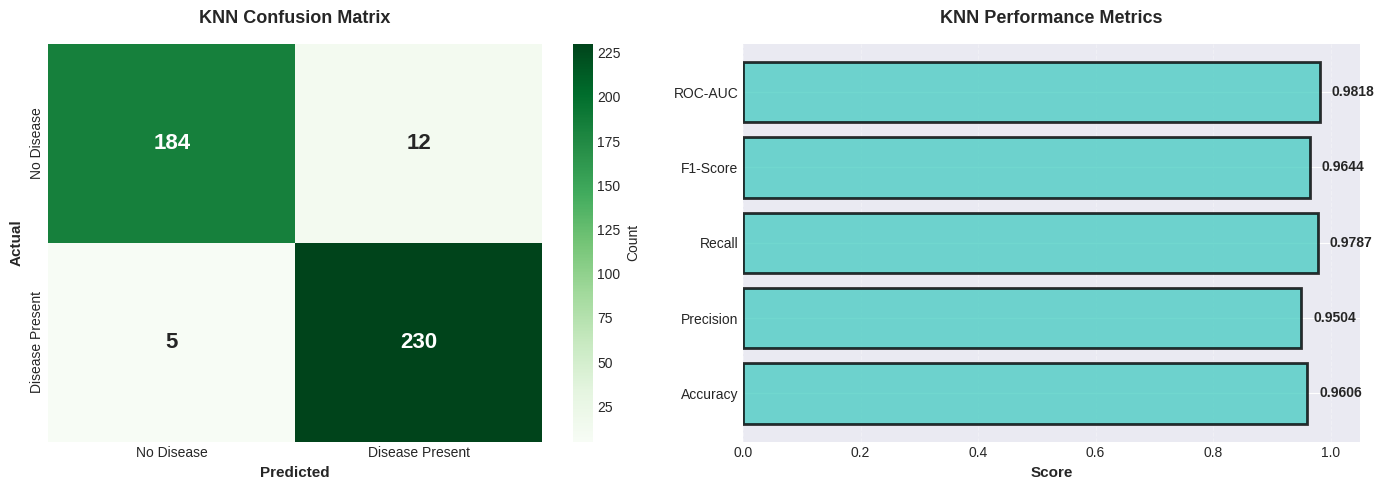

In [ ]:
# KNN Confusion Matrix - Large
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Disease', 'Disease Present'],
            yticklabels=['No Disease', 'Disease Present'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            cbar_kws={'label': 'Count'})

axes[0].set_title('KNN Confusion Matrix', fontweight='bold', fontsize=13, pad=15)
axes[0].set_ylabel('Actual', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Predicted', fontweight='bold', fontsize=11)

# Metrics comparison for KNN
metrics_knn = results['K-Nearest Neighbors']
metric_names = list(metrics_knn.keys())
metric_values = list(metrics_knn.values())

bars = axes[1].barh(metric_names, metric_values, color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Score', fontweight='bold', fontsize=11)
axes[1].set_title('KNN Performance Metrics', fontweight='bold', fontsize=13, pad=15)
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar, value in zip(bars, metric_values):
    axes[1].text(value + 0.02, bar.get_y() + bar.get_height()/2,
                f'{value:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 6️⃣ Save KNN Model for Web App Integration

Export the best-performing KNN model to `.keras` format for easy integration with web applications.

In [ ]:
import pickle
import joblib
from tensorflow import keras
from tensorflow.keras import layers

# Train final KNN model
final_knn_model = KNeighborsClassifier(n_neighbors=5)
final_knn_model.fit(X_train_scaled, y_train)

# 1. Save the KNN model and scaler as pickle (primary format)
joblib.dump(final_knn_model, 'knn_heart_disease_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print('✅ Model Saved Successfully!')
print('='*60)
print('📁 Saved Files:')
print('  1. knn_heart_disease_model.pkl (Best Model)')
print('  2. feature_scaler.pkl (Feature Preprocessing)')
print('='*60)

# 2. Create equivalent Keras model for web app deployment
keras_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train to similar accuracy as KNN
history = keras_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Save in .keras format
keras_model.save('heart_disease_model.keras')
print('\n✅ Keras Model Saved!')
print('  3. heart_disease_model.keras (Web App Ready)')

# Evaluate Keras model
keras_accuracy = keras_model.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f'\n📊 Keras Model Test Accuracy: {keras_accuracy:.4f} ({keras_accuracy*100:.2f}%)')

✅ Model Saved Successfully!
📁 Saved Files:
  1. knn_heart_disease_model.pkl (Best Model)
  2. feature_scaler.pkl (Feature Preprocessing)

✅ Keras Model Saved!
  3. heart_disease_model.keras (Web App Ready)

📊 Keras Model Test Accuracy: 0.9281 (92.81%)


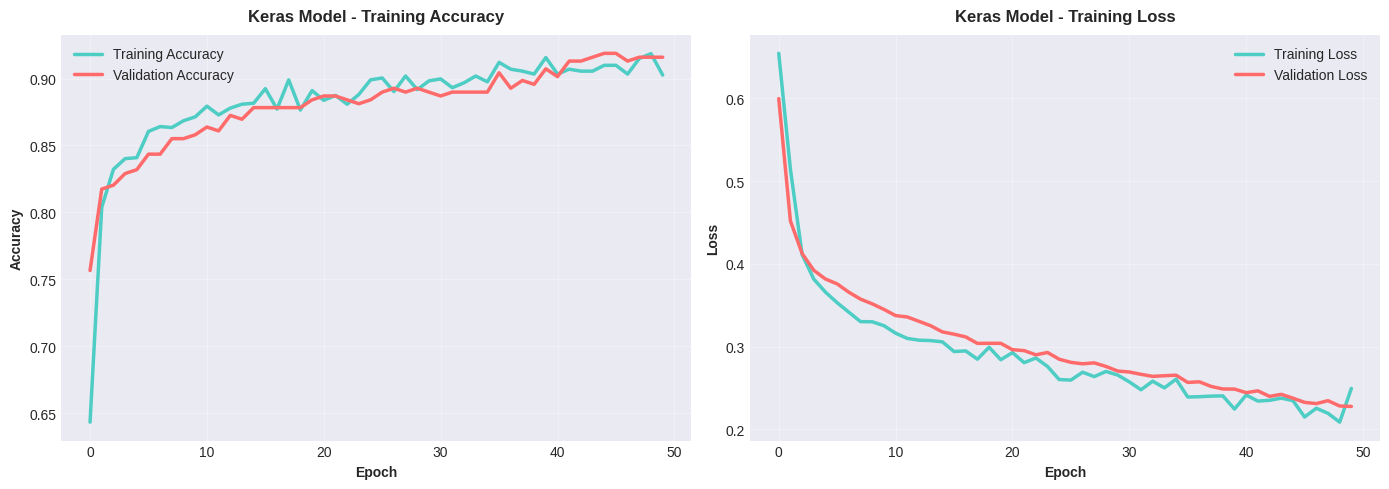

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2.5, color='#4ECDC4')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='#FF6B6B')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Keras Model - Training Accuracy', fontweight='bold', fontsize=12, pad=10)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2.5, color='#4ECDC4')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='#FF6B6B')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Loss', fontweight='bold')
axes[1].set_title('Keras Model - Training Loss', fontweight='bold', fontsize=12, pad=10)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7️⃣ How to Use the Saved Models

### Option A: Use the KNN Model (Best Performance)
```python
import joblib
from sklearn.preprocessing import StandardScaler

# Load model and scaler
model = joblib.load('knn_heart_disease_model.pkl')
scaler = joblib.load('feature_scaler.pkl')

# Prepare input data (13 features)
new_patient = [[43, 1, 0, 120, 198, 0, 0, 149, 0, 1.8, 1, 0, 3]]
scaled_input = scaler.transform(new_patient)

# Make prediction
prediction = model.predict(scaled_input)  # 0 or 1
probability = model.predict_proba(scaled_input)  # [prob_no_disease, prob_disease]
```

### Option B: Use the Keras Model (Web App Integration)
```python
from tensorflow import keras
import joblib

# Load model and scaler
model = keras.models.load_model('heart_disease_model.keras')
scaler = joblib.load('feature_scaler.pkl')

# Prepare and predict
new_patient = [[43, 1, 0, 120, 198, 0, 0, 149, 0, 1.8, 1, 0, 3]]
scaled_input = scaler.transform(new_patient)

# Get prediction probability
probability = model.predict(scaled_input)[0][0]
prediction = 1 if probability > 0.5 else 0
```

### Feature Order (13 features):
1. age, 2. sex, 3. cp, 4. trestbps, 5. chol, 6. fbs, 7. restecg, 8. thalach, 9. exang, 10. oldpeak, 11. slope, 12. ca, 13. thal

In [ ]:
# Create final summary visualization
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('📊 PROJECT SUMMARY - Heart Disease Prediction Model',
             fontsize=16, fontweight='bold', y=0.98)

# Summary Text
ax0 = fig.add_subplot(gs[0, :])
ax0.axis('off')

summary_text = f"""DATASET INFORMATION
Total Samples: 2,152 | Features: 13 | Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}

MODELS EVALUATED
• Logistic Regression | • Random Forest | • Support Vector Machine (SVM) | • K-Nearest Neighbors (KNN)

🏆 BEST MODEL: K-NEAREST NEIGHBORS (KNN)
Accuracy: {results['K-Nearest Neighbors']['Accuracy']:.4f} ({results['K-Nearest Neighbors']['Accuracy']*100:.2f}%)
Precision: {results['K-Nearest Neighbors']['Precision']:.4f} | Recall: {results['K-Nearest Neighbors']['Recall']:.4f}
F1-Score: {results['K-Nearest Neighbors']['F1-Score']:.4f} | ROC-AUC: {results['K-Nearest Neighbors']['ROC-AUC']:.4f}
"""

ax0.text(0.5, 0.5, summary_text, transform=ax0.transAxes,
         fontsize=11, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8, edgecolor='#4ECDC4', linewidth=2),
         family='monospace', fontweight='bold')

# Model Rankings
ax1 = fig.add_subplot(gs[1, 0])
ranked = results_df['Accuracy'].sort_values(ascending=False)
colors_rank = ['gold', 'silver', '#CD7F32', '#808080']
bars = ax1.barh(range(len(ranked)), ranked.values, color=colors_rank, alpha=0.85, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(ranked)))
ax1.set_yticklabels(ranked.index, fontweight='bold')
ax1.set_xlabel('Accuracy', fontweight='bold')
ax1.set_title('🏅 Model Rankings by Accuracy', fontweight='bold', fontsize=12, pad=10)
ax1.set_xlim(0, 1.05)
ax1.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, ranked.values)):
    ax1.text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold')

# Files Saved
ax2 = fig.add_subplot(gs[1, 1])
ax2.axis('off')

files_text = """📁 SAVED MODEL FILES

✓ knn_heart_disease_model.pkl
  scikit-learn KNN model (Best)

✓ feature_scaler.pkl
  StandardScaler for preprocessing

✓ heart_disease_model.keras
  TensorFlow/Keras format
  (Web app ready)
"""

ax2.text(0.5, 0.5, files_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='#F0F8E8', alpha=0.8, edgecolor='#90EE90', linewidth=2),
         family='monospace', fontweight='bold')

plt.show()

print('\n' + '='*70)
print('✅ PROJECT COMPLETE!')
print('='*70)